# Notebook 10 — Ortomosaico Real del P4M (WebODM, sin banda Blue)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/miguepoloc/teledeteccion/blob/main/sesiones/sesion-04/colab/03_rasterio_ortomosaico_real_webodm.ipynb)

**Teledetección — Maestría en Ingeniería | Universidad del Magdalena**
**Sesión 4 | Sábado 25 Jul 2026**

Este notebook analiza el ortomosaico **real** que WebODM generó para el vuelo de esta sesión (formato **GeoTIFF (Raw)**, descargado desde el panel de resultados del proyecto: Download → Orthophoto → Format: GeoTIFF (Raw)). A diferencia del [Notebook 00](00_rasterio_dron_analisis.ipynb) —que asume el set ideal de 5 bandas del sensor (Blue, Green, Red, Red Edge, NIR)—, **este vuelo no incluye la banda Blue** entre sus capturas, así que trabajamos con las 4 bandas espectrales realmente disponibles más el canal alpha que WebODM agrega como máscara de datos válidos.

### Lo que haremos
1. Cargar el ortomosaico real de WebODM (4 bandas + alpha)
2. Visualizar cada banda y una composición falso color (sin RGB verdadero, por falta de Blue)
3. Calcular NDVI, NDRE y SAVI (todos calculables sin Blue), usando la máscara alpha para excluir el área fuera del vuelo
4. Hacer estadísticas básicas por zona
5. Exportar los resultados como GeoTIFF

### Bandas de este ortomosaico (según metadatos embebidos por WebODM)
| Banda en el archivo | Nombre |
|----------------------|--------|
| 1 | Red (650 nm) |
| 2 | Green (560 nm) |
| 3 | NIR (840 nm) |
| 4 | Red Edge (730 nm) |
| 5 | Alpha (máscara de datos válidos, no es una banda espectral) |

**Nota:** el sensor P4M sí captura Blue (450 nm), pero este vuelo específico no la incluyó — mismo caso ya documentado en el [Notebook 02](02_shift_manual_bandas.ipynb) (sección "Nota sobre las bandas").

---

## Parte 0 — Instalación

In [1]:
# En entorno local (Conda `teledeteccion`): rasterio ya debe estar instalado
# En Colab:
try:
    import rasterio
    print(f'rasterio {rasterio.__version__} — OK')
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'rasterio', '--quiet'])
    import rasterio

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print('Librerías listas')

rasterio 1.5.0 — OK
Librerías listas


## Parte 1 — Cargar el ortomosaico real

El archivo de este vuelo (`ortomosaico_p4m_real_4bandas.tif`) se descargó desde WebODM eligiendo **Format: GeoTIFF (Raw)** — ese formato conserva las bandas calibradas como reflectancia (`float32`) en vez de convertirlas a una imagen visual RGB de 8 bits (eso sería `GeoTIFF (RGB)`, que NO sirve para calcular índices).

Este notebook busca el archivo en dos lugares posibles, en este orden (mismo patrón que el Notebook 02):
1. **Ruta local del repo** (`RUTA_BASE` abajo) — funciona si ejecutas el notebook desde `colab/` dentro del repo clonado, con `datos/` sincronizado.
2. **Carpeta actual de Colab** — si subiste el `.tif` directamente a la sesión de Colab.

Si no aparece en ninguna, sube el `.tif` manualmente.

In [2]:
import os

NOMBRE_ARCHIVO = 'ortomosaico_p4m_real_4bandas.tif'
RUTA_BASE = '../../../datos'  # ruta local del repo, relativa a sesiones/sesion-04/colab/

candidatos = [f'{RUTA_BASE}/{NOMBRE_ARCHIVO}', NOMBRE_ARCHIVO]
RUTA_ORTO = next((r for r in candidatos if os.path.exists(r)), None)

if RUTA_ORTO is None:
    print(f'⚠ No se encontró {NOMBRE_ARCHIVO} ni en {RUTA_BASE}/ ni en la carpeta actual.')
    print('Sube el archivo (WebODM → Download → Orthophoto → Format: GeoTIFF (Raw)):')
    print('  # from google.colab import files; uploaded = files.upload()')
else:
    with rasterio.open(RUTA_ORTO) as src:
        print('=== Metadatos del ortomosaico real (WebODM) ===')
        print(f'Archivo:     {RUTA_ORTO}')
        print(f'Dimensiones: {src.width} × {src.height} px')
        print(f'Bandas:      {src.count}  →  {src.descriptions}')
        print(f'CRS:         {src.crs}')
        print(f'Resolución:  {src.res[0]*100:.1f} cm/px')
        print(f'Dtype:       {src.dtypes[0]}')

=== Metadatos del ortomosaico real (WebODM) ===
Archivo:     ../../../datos/ortomosaico_p4m_real_4bandas.tif
Dimensiones: 534 × 648 px
Bandas:      5  →  ('Red', 'Green', 'NIR', 'RedEdge', None)
CRS:         EPSG:32618
Resolución:  5.0 cm/px
Dtype:       float32


## Parte 2 — Leer las bandas y aplicar la máscara de datos válidos

El ortomosaico tiene una **banda 5 de alpha** (0 = fuera del área volada, 255 = dato válido) — no es una banda espectral, así que la separamos como máscara en vez de tratarla como si fuera NIR o cualquier otra banda.

Píxeles dentro del área volada: 80.3%


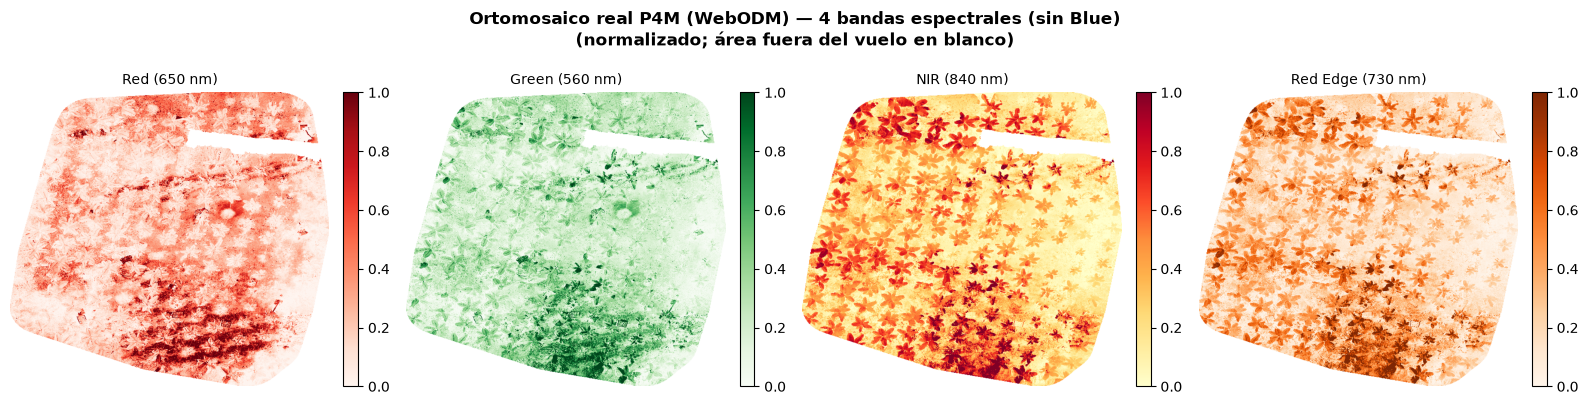

In [3]:
with rasterio.open(RUTA_ORTO) as src:
    red   = src.read(1).astype(np.float32)
    green = src.read(2).astype(np.float32)
    nir   = src.read(3).astype(np.float32)
    re    = src.read(4).astype(np.float32)
    alpha = src.read(5)
    perfil = src.profile.copy()

mascara_valida = alpha > 0
print(f'Píxeles dentro del área volada: {100 * mascara_valida.mean():.1f}%')

def normalizar(banda, mascara, percentil=2):
    p_low, p_high = np.percentile(banda[mascara], [percentil, 100 - percentil])
    resultado = np.clip((banda - p_low) / (p_high - p_low + 1e-6), 0, 1)
    resultado[~mascara] = np.nan
    return resultado

nombres = ['Red (650 nm)', 'Green (560 nm)', 'NIR (840 nm)', 'Red Edge (730 nm)']
bandas_raw = [red, green, nir, re]
colormaps = ['Reds', 'Greens', 'YlOrRd', 'Oranges']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, banda, nombre, cmap in zip(axes, bandas_raw, nombres, colormaps):
    im = ax.imshow(normalizar(banda, mascara_valida), cmap=cmap, aspect='auto')
    ax.set_title(nombre, fontsize=10)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('Ortomosaico real P4M (WebODM) — 4 bandas espectrales (sin Blue)\n(normalizado; área fuera del vuelo en blanco)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

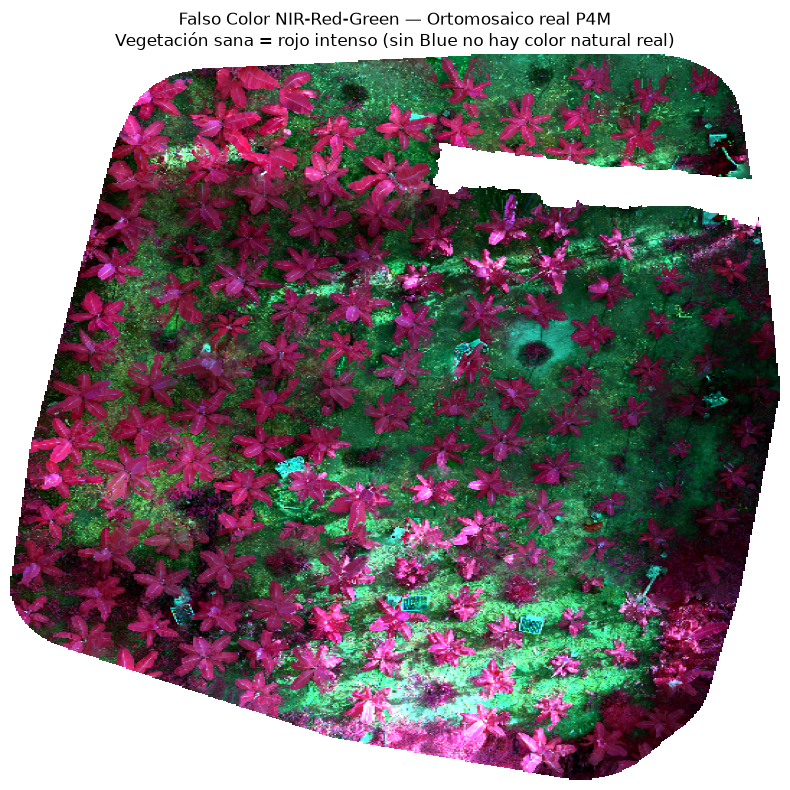

In [4]:
# Sin banda Blue no se puede armar color natural real (R-G-B);
# usamos falso color infrarrojo (NIR-Red-Green), igual que el Notebook 02
cir = np.dstack([normalizar(nir, mascara_valida), normalizar(red, mascara_valida), normalizar(green, mascara_valida)])

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(cir, aspect='auto')
ax.set_title('Falso Color NIR-Red-Green — Ortomosaico real P4M\nVegetación sana = rojo intenso (sin Blue no hay color natural real)', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

## Parte 3 — Calcular índices espectrales

Con Red, NIR y Red Edge alcanza para NDVI, NDRE y SAVI. La aproximación de NDMI del Notebook 00 usaba la banda Blue — sin ella no se puede calcular ni siquiera esa aproximación, así que no aparece en este notebook.

Los índices se recortan a su rango teórico (p. ej. NDVI ∈ [-1, 1]) porque la reflectancia calibrada real tiene ruido cerca de cero que puede disparar el valor cuando NIR+Red ≈ 0 — algo que no pasaba con los datos sintéticos del Notebook 00.

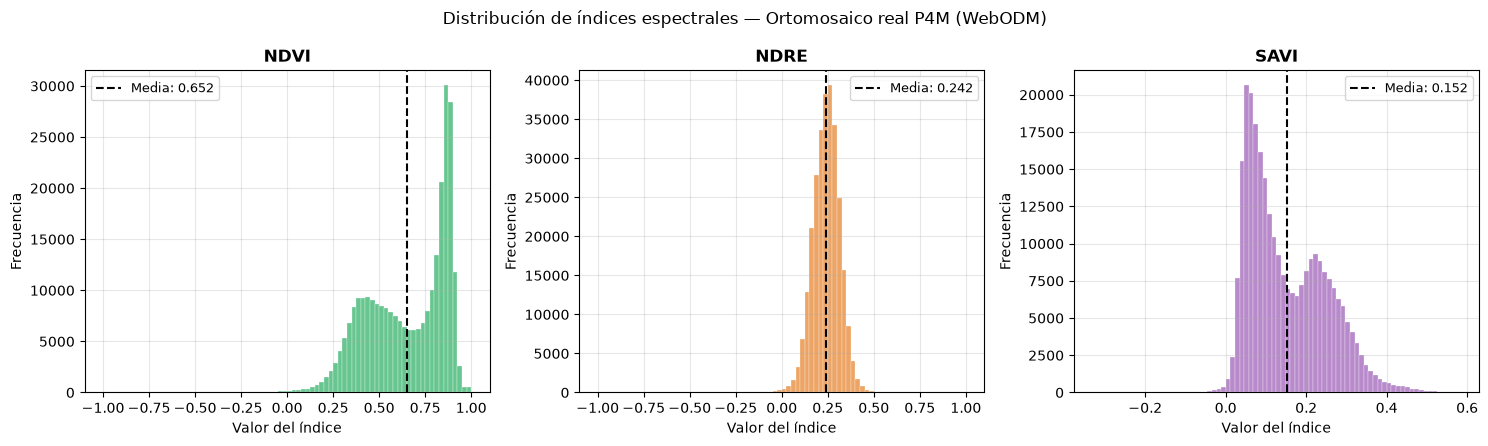

In [5]:
eps = 1e-6

ndvi = np.clip((nir - red) / (nir + red + eps), -1, 1)
ndre = np.clip((nir - re)  / (nir + re  + eps), -1, 1)
savi = np.clip(1.5 * (nir - red) / (nir + red + 0.5 + eps), -1.5, 1.5)

for arr in (ndvi, ndre, savi):
    arr[~mascara_valida] = np.nan

datos_indices = [(ndvi, 'NDVI', '#27ae60'), (ndre, 'NDRE', '#e67e22'), (savi, 'SAVI', '#9b59b6')]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (idx, nombre, color) in zip(axes, datos_indices):
    valores = idx[mascara_valida]
    ax.hist(valores, bins=80, color=color, alpha=0.7, edgecolor='white', linewidth=0.3)
    ax.axvline(np.nanmean(valores), color='black', linestyle='--', linewidth=1.5,
               label=f'Media: {np.nanmean(valores):.3f}')
    ax.set_title(nombre, fontsize=12, fontweight='bold')
    ax.set_xlabel('Valor del índice')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Distribución de índices espectrales — Ortomosaico real P4M (WebODM)', fontsize=12)
plt.tight_layout()
plt.show()

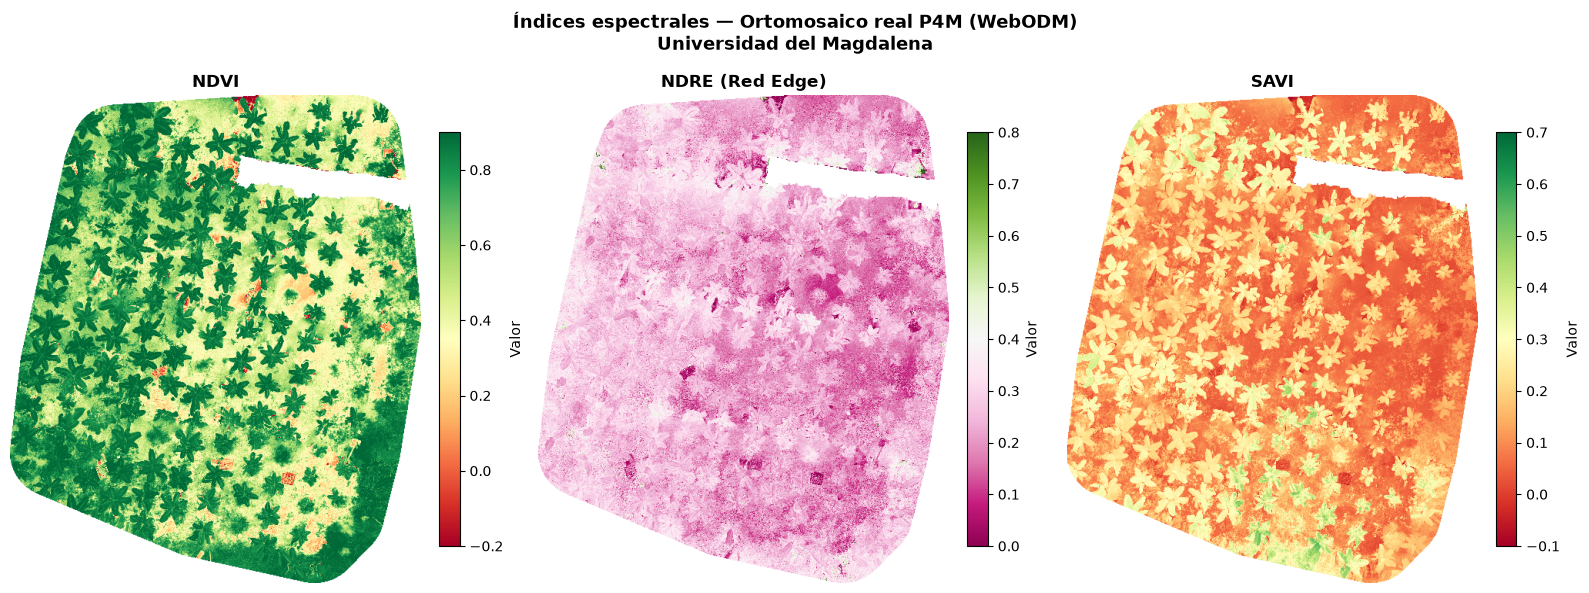

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

configs = [
    (ndvi, 'NDVI', 'RdYlGn', (-0.2, 0.9)),
    (ndre, 'NDRE (Red Edge)', 'PiYG', (0.0, 0.8)),
    (savi, 'SAVI', 'RdYlGn', (-0.1, 0.7)),
]

for ax, (idx, titulo, cmap, (vmin, vmax)) in zip(axes, configs):
    im = ax.imshow(idx, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.axis('off')
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Valor')

plt.suptitle('Índices espectrales — Ortomosaico real P4M (WebODM)\nUniversidad del Magdalena', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Parte 4 — Estadísticas por cobertura

In [7]:
# Separar coberturas usando umbrales de NDVI (mismo esquema del Notebook 00)
mascara_agua       = mascara_valida & (ndvi < 0.05)
mascara_suelo      = mascara_valida & (ndvi >= 0.05) & (ndvi < 0.25)
mascara_cesped     = mascara_valida & (ndvi >= 0.25) & (ndvi < 0.50)
mascara_vegetacion = mascara_valida & (ndvi >= 0.50)

coberturas = {
    'Agua / suelo húmedo': mascara_agua,
    'Suelo desnudo':        mascara_suelo,
    'Césped / pastizal':    mascara_cesped,
    'Vegetación densa':     mascara_vegetacion,
}

print(f"{'Cobertura':<25} {'Píxeles':>8} {'%':>6} {'NDVI':>6} {'NDRE':>6} {'SAVI':>6}")
print('-' * 60)
total_px = int(mascara_valida.sum())
for nombre, mascara in coberturas.items():
    n = int(mascara.sum())
    pct = 100 * n / total_px if total_px else 0
    ndvi_m = np.nanmean(ndvi[mascara]) if n > 0 else 0
    ndre_m = np.nanmean(ndre[mascara]) if n > 0 else 0
    savi_m = np.nanmean(savi[mascara]) if n > 0 else 0
    print(f'{nombre:<25} {n:>8,} {pct:>6.1f}% {ndvi_m:>6.3f} {ndre_m:>6.3f} {savi_m:>6.3f}')

Cobertura                  Píxeles      %   NDVI   NDRE   SAVI
------------------------------------------------------------
Agua / suelo húmedo          1,314    0.5% -0.188 -0.005 -0.013
Suelo desnudo                6,846    2.5%  0.189  0.104  0.034
Césped / pastizal           73,104   26.3%  0.395  0.184  0.066
Vegetación densa           196,651   70.8%  0.769  0.270  0.189


## Parte 5 — Exportar resultados como GeoTIFF

In [8]:
def exportar_indice_geotiff(array, nombre_archivo, perfil_referencia, mascara_valida):
    perfil_out = perfil_referencia.copy()
    perfil_out.update({'count': 1, 'dtype': 'float32', 'nodata': -9999})

    data = array.astype(np.float32).copy()
    data[~mascara_valida] = -9999
    data[np.isnan(data)] = -9999

    with rasterio.open(nombre_archivo, 'w', **perfil_out) as dst:
        dst.write(data, 1)
    print(f'Exportado: {nombre_archivo}')

exportar_indice_geotiff(ndvi, 'ndvi_dron_real_webodm.tif', perfil, mascara_valida)
exportar_indice_geotiff(ndre, 'ndre_dron_real_webodm.tif', perfil, mascara_valida)
exportar_indice_geotiff(savi, 'savi_dron_real_webodm.tif', perfil, mascara_valida)

print()
print('Abre estos archivos en QGIS para ver los índices georreferenciados (CRS: EPSG:32618).')

Exportado: ndvi_dron_real_webodm.tif
Exportado: ndre_dron_real_webodm.tif
Exportado: savi_dron_real_webodm.tif

Abre estos archivos en QGIS para ver los índices georreferenciados (CRS: EPSG:32618).


---
## Resumen
Trabajaste con datos reales de tu propio vuelo, no con datos sintéticos:
1. El ortomosaico de WebODM en formato **GeoTIFF (Raw)** ya viene con las bandas calibradas — no hace falta el `gdal_merge.py` del `guia_webodm_p4m.md` si descargas ese formato directamente
2. Una banda alpha (0/255) marca qué píxeles están dentro del área volada — hay que enmascararla antes de calcular índices o estadísticas
3. Sin la banda Blue, NDVI/NDRE/SAVI se calculan igual (usan Red/NIR/RedEdge), pero no hay color natural real ni la aproximación de NDMI del Notebook 00
4. Recortar los índices a su rango teórico evita valores disparados por ruido en reflectancias cercanas a cero

Compara estos resultados contra el [Notebook 00](00_rasterio_dron_analisis.ipynb) (datos ideales/sintéticos) y el [Notebook 02](02_shift_manual_bandas.ipynb) (shift manual sobre una captura sin procesar) para ver los tres caminos: sintético, manual, y automático (WebODM).